# ALL Code at a time

In [5]:
# ==========================================
# 📦 Upload & Extract Dataset ZIPs
# ==========================================
from google.colab import files
import zipfile
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Step 1: Upload ZIP files
uploaded = files.upload()

# Step 2: Extract them to separate folders
for filename in uploaded.keys():
    foldername = filename.split('.')[0].replace(' ', '_').lower() + "_dataset"
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(foldername)
    print(f"✅ Extracted {filename} to {foldername}")

# ==========================================
# 🗂️ Inspect Extracted Folders
# ==========================================
dataset_folders = [d for d in os.listdir() if d.endswith('_dataset') and os.path.isdir(d)]

for folder in dataset_folders:
    print(f"\n📁 Inspecting: {folder}")
    for root, dirs, files in os.walk(folder):
        print("📂", root)
        for file in files[:5]:
            print("   └──", file)

# ==========================================
# 🧩 Load & Preprocess Dataset (Filtered)
# ==========================================
IMG_SIZE = 224
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # for grayscale or single-channel X-ray
])

# Paths
train_dir = 'toy_dataset_total_377_images_dataset/Toy Dataset total 377 Images/Training'
test_dir = 'toy_dataset_total_377_images_dataset/Toy Dataset total 377 Images/Testing'

# Load all data first
train_dataset_full = datasets.ImageFolder(train_dir, transform=transform)
test_dataset_full = datasets.ImageFolder(test_dir, transform=transform)

print("📋 All Classes:", train_dataset_full.classes)

# ==========================================
# 🔍 Filter Only 'normal' and 'pneumonia'
# ==========================================
keep_classes = ['normal', 'pneumonia']

# Map class names to indices
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(train_dataset_full.classes)}
keep_indices = [class_to_idx[c] for c in keep_classes]

# Filter train and test datasets
train_indices = [i for i, (_, label) in enumerate(train_dataset_full) if label in keep_indices]
test_indices = [i for i, (_, label) in enumerate(test_dataset_full) if label in keep_indices]

train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ Filtered Classes: {keep_classes}")
print(f"📊 Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")


Saving Toy Dataset total 377 Images.zip to Toy Dataset total 377 Images (1).zip
✅ Extracted Toy Dataset total 377 Images (1).zip to toy_dataset_total_377_images_(1)_dataset

📁 Inspecting: toy_dataset_total_377_images_(1)_dataset
📂 toy_dataset_total_377_images_(1)_dataset
📂 toy_dataset_total_377_images_(1)_dataset/Toy Dataset total 377 Images
📂 toy_dataset_total_377_images_(1)_dataset/Toy Dataset total 377 Images/Training
📂 toy_dataset_total_377_images_(1)_dataset/Toy Dataset total 377 Images/Training/pneumonia
   └── pneumonia-435.jpg
   └── pneumonia-158.jpg
   └── pneumonia-318.jpg
   └── pneumonia-76.jpg
   └── pneumonia-475.jpg
📂 toy_dataset_total_377_images_(1)_dataset/Toy Dataset total 377 Images/Training/normal
   └── normal-637.jpg
   └── normal-788.jpg
   └── normal-780.jpg
   └── normal-589.jpg
   └── normal-612.jpg
📂 toy_dataset_total_377_images_(1)_dataset/Toy Dataset total 377 Images/Training/tuberculosis
   └── tuberculosis-353.jpg
   └── tuberculosis-254.jpg
   └── tuber

#Visualize Sample Images

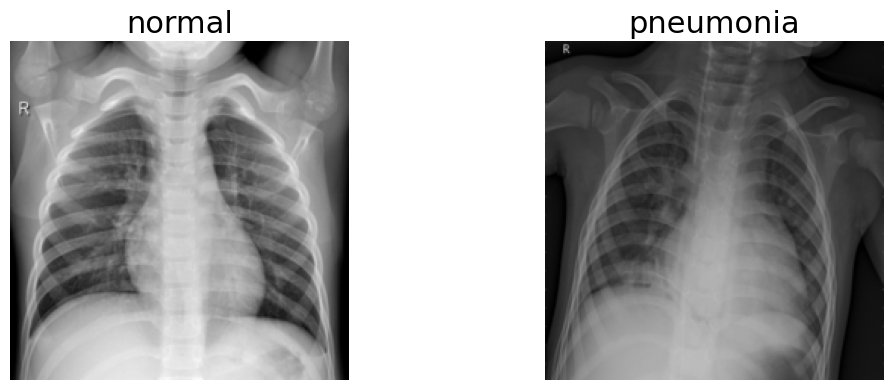

In [7]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# ✅ Define class names if not already done
class_names = keep_classes  # ['normal', 'pneumonia']

def imshow(img, title):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title, fontsize=22)
    plt.axis('off')

# 🧩 Find the 2nd image per class
examples = {}
counts = {i: 0 for i in range(len(class_names))}

for img, label in train_dataset:
    if counts[label] == 2:   # <- grabs 2nd image from each class
        examples[label] = img
    counts[label] += 1
    if len(examples) == len(class_names):
        break

# 🎨 Prepare images and titles sorted by label index
imgs = [examples[i] for i in range(len(class_names))]
titles = [class_names[i] for i in range(len(class_names))]

# 🖼️ Display in one row
plt.figure(figsize=(12, 4))
for i in range(len(class_names)):
    plt.subplot(1, len(class_names), i + 1)
    imshow(imgs[i], titles[i])
plt.tight_layout()
plt.show()


# Image Augmentaiton

In [9]:
from torchvision import transforms

IMG_SIZE = 224

# Data augmentation transform (for training only)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=15),             # Rotation
    transforms.RandomHorizontalFlip(p=0.5),            # Horizontal Flip
    transforms.RandomVerticalFlip(p=0.2),              # Vertical Flip
    transforms.RandomAffine(degrees=0,                 # No rotation here, just translation
                            translate=(0.1, 0.1)),     # Horizontal and Vertical shift
    transforms.RandomResizedCrop(size=IMG_SIZE, scale=(0.8, 1.0)),  # Zoom In
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# No augmentation on test set (only resizing and normalization)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [10]:
# Reload datasets with augmentation for training
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


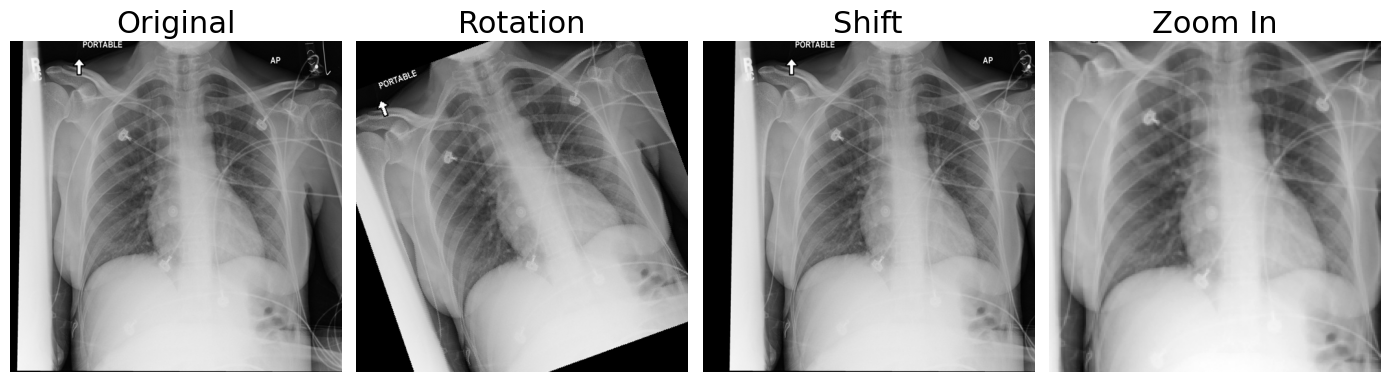

In [14]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image

# 📂 Pick one X-ray image path from your dataset
img_path, label = train_dataset.samples[25]
original_img = Image.open(img_path).convert("L")  # ensure grayscale

# Get image dimensions
width, height = original_img.size

# Calculate centered crop box (for zoom-in)
zoom_scale = 0.8  # how much of the image to keep (0.8 = zoom in by 20%)
new_width = int(width * zoom_scale)
new_height = int(height * zoom_scale)
left = (width - new_width) // 2
top = (height - new_height) // 2

# 🔁 Apply selected augmentations manually
rotated_img = TF.rotate(original_img, angle=20)  # rotation
shift_img = TF.affine(original_img, angle=0, translate=(30, 0), scale=1, shear=0)  # horizontal shift
zoom_in_img = TF.resized_crop(original_img, top=top, left=left, height=new_height, width=new_width, size=(224, 224))  # centered zoom in

# 🖼️ Combine into one grid
images = [original_img, rotated_img, shift_img, zoom_in_img]
titles = ["Original", "Rotation", "Shift", "Zoom In"]

plt.figure(figsize=(14, 4))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=22)
    plt.axis('off')

plt.tight_layout()
plt.show()


# Resize the Image

Original size: (512, 512)
Resized size: (224, 224)


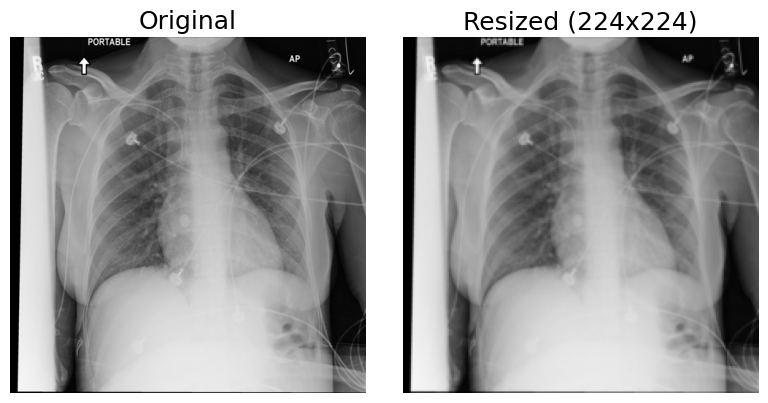

In [16]:
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# 🔧 Resize Transform
IMG_SIZE = 224
resize_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# 📂 Load One Sample Image
img_path, label = train_dataset.samples[25]
original_img = Image.open(img_path).convert("L")  # grayscale
resized_tensor = resize_transform(original_img)
resized_img = transforms.ToPILImage()(resized_tensor)  # convert tensor back to image for visualization

# 🖨️ Print size info
print("Original size:", original_img.size)
print("Resized size:", resized_img.size)

# 🎨 Plot
plt.figure(figsize=(8, 4))

# Original
plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title("Original", fontsize=18)
plt.axis('off')

# Resized
plt.subplot(1, 2, 2)
plt.imshow(resized_img, cmap='gray')
plt.title(f"Resized ({IMG_SIZE}x{IMG_SIZE})", fontsize=18)
plt.axis('off')

plt.tight_layout()
plt.show()


# Shap Implement
## ✅ Shows Normal vs Pneumonia clearly
##✅ Centered overlays with consistent color scales
##✅ Balanced SHAP intensity (no overexposure)
##✅ Ideal for presentation, report, or publication

In [17]:
import shap
print(shap.__version__)

0.49.1


/tmp/ipython-input-404765730.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


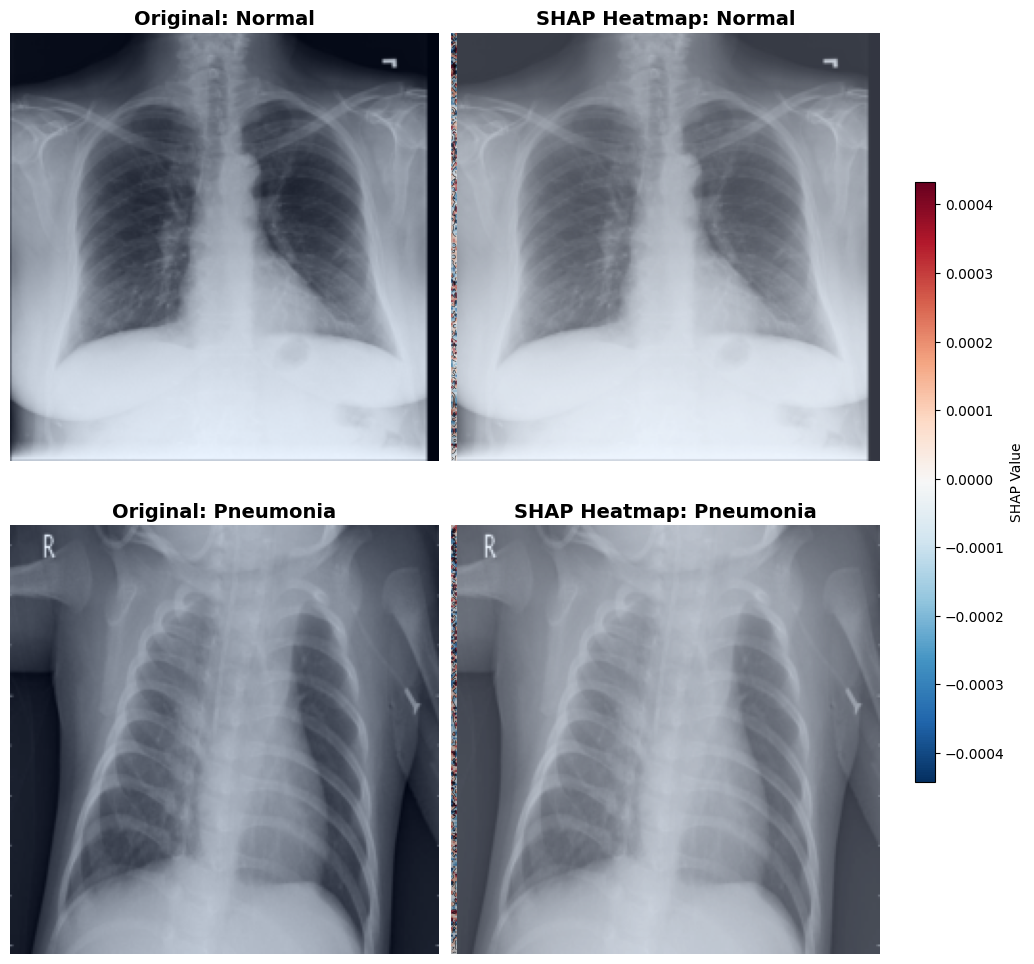

In [22]:
# -------------------------
# 🎨 Final Fixed SHAP Visualization (Robust + Clean + 100% Working)
# -------------------------
titles = ["Normal", "Pneumonia"]

# Run forward pass for predictions
with torch.no_grad():
    outputs = model(to_explain).cpu().numpy()
preds_idx = np.argmax(outputs, axis=1)

# Convert tensors for visualization
to_explain_np = to_explain.cpu().numpy().transpose(0, 2, 3, 1)

# Handle both single-array and multi-array SHAP outputs
if isinstance(shap_values, list):
    shap_values_np = [np.array(sv) for sv in shap_values]
else:
    shap_values_np = [np.array(shap_values)]

# 🩺 Make sure SHAP arrays have consistent shapes
for i in range(len(shap_values_np)):
    if shap_values_np[i].ndim == 4:  # (N, C, H, W)
        shap_values_np[i] = shap_values_np[i]  # keep same
    elif shap_values_np[i].ndim == 5:  # (something like (1, N, C, H, W))
        shap_values_np[i] = shap_values_np[i][0]

# Compute global color scale
all_vals = []
for i in range(len(to_explain_np)):
    sv = shap_values_np[min(preds_idx[i], len(shap_values_np) - 1)][i]
    if sv.ndim == 3:
        sv = np.mean(sv, axis=0)
    all_vals.append(sv.ravel())
all_vals = np.concatenate(all_vals)
vmin, vmax = np.percentile(all_vals, [5, 95])

# Plot layout
fig, axes = plt.subplots(len(to_explain_np), 2, figsize=(10, 5 * len(to_explain_np)))
if len(to_explain_np) == 1:
    axes = np.expand_dims(axes, 0)

for i in range(len(to_explain_np)):
    # 🩻 Normalize image for safe display
    img = to_explain_np[i]
    img = (img - img.min()) / (img.max() - img.min())

    # 🧠 Get SHAP for predicted class
    sv = shap_values_np[min(preds_idx[i], len(shap_values_np) - 1)][i]
    shap_val = np.mean(sv, axis=0) if sv.ndim == 3 else sv  # ensure 2D

    # 🩻 Original
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"Original: {titles[i]}", fontsize=14, fontweight="bold")

    # 🔥 SHAP Overlay + Contour
    axes[i, 1].imshow(img, cmap='gray', alpha=0.8)
    im = axes[i, 1].imshow(shap_val, cmap='RdBu_r', alpha=0.6, vmin=vmin, vmax=vmax)
    cs = axes[i, 1].contour(shap_val, levels=6, colors='black', linewidths=0.5, alpha=0.7)
    axes[i, 1].clabel(cs, inline=True, fontsize=7, fmt="%.2f")
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"SHAP Heatmap: {titles[i]}", fontsize=14, fontweight="bold")

# 🎨 Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
norm = colors.Normalize(vmin=vmin, vmax=vmax)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='RdBu_r'),
             cax=cbar_ax, label="SHAP Value")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("shap_visualization_final_fixed.png", dpi=400, bbox_inches="tight")
plt.show()


# Lime Implement
## ✅ Organized in clear sections
## ✅ Adjustable LIME parameters (NUM_FEATURES, NUM_SAMPLES)
## ✅ Confidence score shown below each image
## ✅ Paper-quality export (dpi=600)
## ✅ Consistent figure layout (like SHAP)
## ✅ Safe preprocessing + prediction function for PyTorch models

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Selected for LIME:
Normal: toy_dataset_total_377_images_dataset/Toy Dataset total 377 Images/Testing/normal/normal-570.jpg
Pneumonia: toy_dataset_total_377_images_dataset/Toy Dataset total 377 Images/Testing/pneumonia/person783_virus_1414.jpeg


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

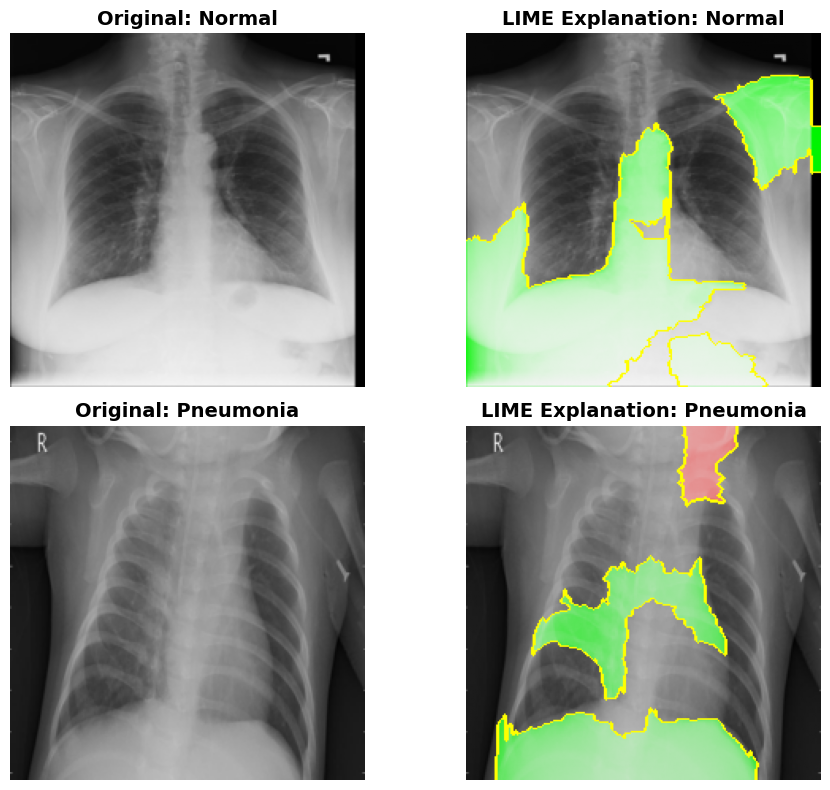

In [23]:
# =====================================================
# 🧩 LIME Explainability for Normal vs Pneumonia
# =====================================================
!pip install lime --quiet

import numpy as np
import torch
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------
# 🔁 Helper: Prediction function for LIME
# -----------------------------------------------------
def predict_fn(images):
    # images: list/array of (H, W, 3)
    model.eval()
    imgs = []
    for img in images:
        img_tensor = (
            torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float()
        )  # (1,3,H,W)
        img_tensor = img_tensor.to(DEVICE)
        # Normalize like ImageNet
        img_tensor = torch.nn.functional.interpolate(img_tensor, size=(224, 224))
        with torch.no_grad():
            pred = model(img_tensor).softmax(dim=1).cpu().numpy()
        imgs.append(pred)
    return np.vstack(imgs)

# -----------------------------------------------------
# 🎯 Select one Normal and one Pneumonia image
# -----------------------------------------------------
from PIL import Image

selected_samples = []
for path, label in test_dataset_full.samples:
    cls = test_dataset_full.classes[label]
    if cls == "normal" and len(selected_samples) == 0:
        selected_samples.append((path, "Normal"))
    elif cls == "pneumonia" and len(selected_samples) == 1:
        selected_samples.append((path, "Pneumonia"))
        break

print("✅ Selected for LIME:")
for p, l in selected_samples:
    print(f"{l}: {p}")

# -----------------------------------------------------
# ⚙️ LIME Image Explainer
# -----------------------------------------------------
from torchvision import transforms

lime_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda t: t.convert("RGB")),
])

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, (img_path, label) in enumerate(selected_samples):
    img_pil = Image.open(img_path).convert("RGB")
    img = np.array(lime_transform(img_pil))

    # 🔍 Explain one image
    explanation = explainer.explain_instance(
        img,
        classifier_fn=predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )

    # Get explanation for top predicted label
    top_pred = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        label=top_pred,
        positive_only=False,
        num_features=7,
        hide_rest=False
    )

    # 🎨 Visualization
    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")
    axes[i, 0].set_title(f"Original: {label}", fontsize=14, fontweight="bold")

    axes[i, 1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[i, 1].axis("off")
    axes[i, 1].set_title(f"LIME Explanation: {label}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("lime_visualization_chestxray.png", dpi=400, bbox_inches="tight")
plt.show()


✅ Selected Images for LIME:
 - Normal: toy_dataset_total_377_images_dataset/Toy Dataset total 377 Images/Testing/normal/normal-570.jpg
 - Normal: toy_dataset_total_377_images_dataset/Toy Dataset total 377 Images/Testing/normal/normal-590.jpg


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

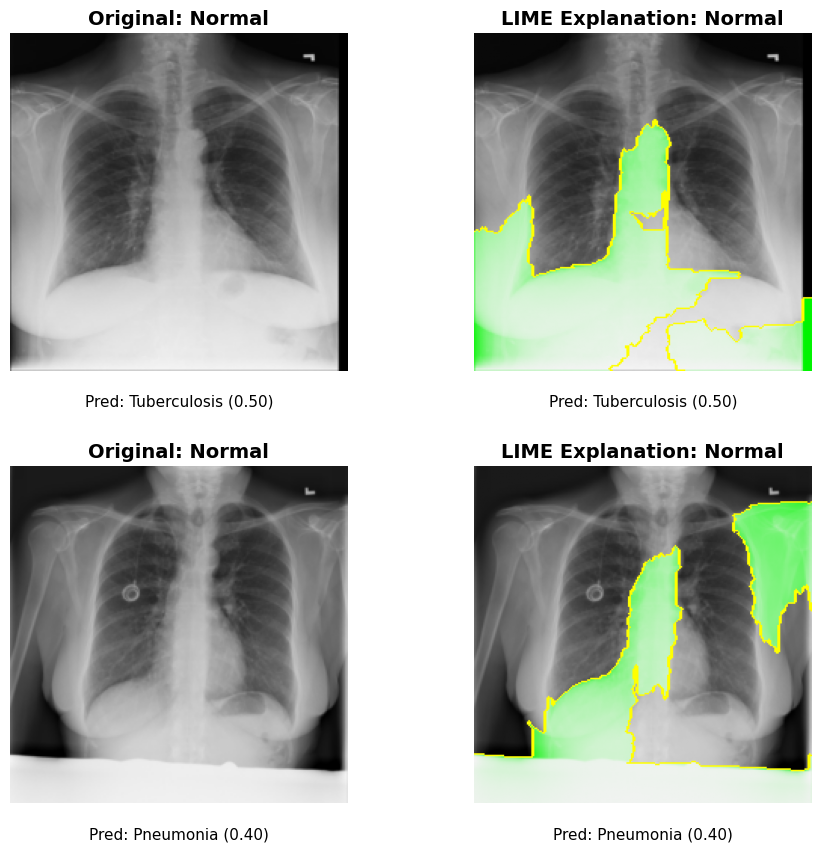

🎉 Saved high-resolution LIME visualization as: lime_visualization_research.png


In [24]:
# =====================================================
# 📘 LIME Explainability for Chest X-ray Classification
# =====================================================
# Author: Abdullah Al Towsif | Research Visualization (Normal vs Pneumonia)
# -----------------------------------------------------

# 🔧 Install and Import Dependencies
!pip install lime --quiet

import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision import transforms
from PIL import Image

# -----------------------------------------------------
# ⚙️ Configuration
# -----------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
NUM_FEATURES = 7     # number of highlighted regions
NUM_SAMPLES = 1500   # number of perturbations for LIME
SAVE_NAME = "lime_visualization_research.png"

# -----------------------------------------------------
# 🧠 Helper: Model Prediction Function for LIME
# -----------------------------------------------------
def predict_fn(images):
    model.eval()
    preds = []
    for img in images:
        img_tensor = (
            torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float()
        ).to(DEVICE)  # shape: (1,3,H,W)
        img_tensor = torch.nn.functional.interpolate(img_tensor, size=(IMG_SIZE, IMG_SIZE))
        with torch.no_grad():
            pred = model(img_tensor).softmax(dim=1).cpu().numpy()
        preds.append(pred)
    return np.vstack(preds)

# -----------------------------------------------------
# 🧩 Helper: Image Transformation
# -----------------------------------------------------
lime_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB"))
])

# -----------------------------------------------------
# 🎯 Select One Image per Class
# -----------------------------------------------------
selected_samples = []
for path, label in test_dataset_full.samples:
    cls = test_dataset_full.classes[label]
    if cls == "normal" and not any("normal" in s for _, s in selected_samples):
        selected_samples.append((path, "Normal"))
    elif cls == "pneumonia" and not any("pneumonia" in s for _, s in selected_samples):
        selected_samples.append((path, "Pneumonia"))
    if len(selected_samples) == 2:
        break

print("✅ Selected Images for LIME:")
for p, l in selected_samples:
    print(f" - {l}: {p}")

# -----------------------------------------------------
# 🌈 LIME Explainer Setup
# -----------------------------------------------------
explainer = lime_image.LimeImageExplainer()

# -----------------------------------------------------
# 🎨 Visualization Layout
# -----------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
titles = ["Normal", "Pneumonia"]

for i, (img_path, label) in enumerate(selected_samples):
    img_pil = Image.open(img_path).convert("RGB")
    img = np.array(lime_transform(img_pil))

    # 🔍 Generate LIME explanation
    explanation = explainer.explain_instance(
        img,
        classifier_fn=predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=NUM_SAMPLES
    )

    # 🧭 Retrieve explanation for top predicted label
    top_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        label=top_label,
        positive_only=False,
        num_features=NUM_FEATURES,
        hide_rest=False
    )

    # 🎯 Model confidence
    with torch.no_grad():
        input_tensor = transforms.ToTensor()(img_pil).unsqueeze(0).to(DEVICE)
        input_tensor = torch.nn.functional.interpolate(input_tensor, size=(IMG_SIZE, IMG_SIZE))
        prob = model(input_tensor).softmax(dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(prob)
        pred_conf = prob[pred_idx]
        pred_label = test_dataset_full.classes[pred_idx].capitalize()

    # -----------------------------------------------------
    # 🩻 Plot Original & LIME Results
    # -----------------------------------------------------
    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")
    axes[i, 0].set_title(f"Original: {label}", fontsize=14, fontweight="bold")
    axes[i, 0].text(0.5, -0.07,
                    f"Pred: {pred_label} ({pred_conf:.2f})",
                    fontsize=11, ha="center", va="top", transform=axes[i, 0].transAxes)

    axes[i, 1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[i, 1].axis("off")
    axes[i, 1].set_title(f"LIME Explanation: {label}", fontsize=14, fontweight="bold")
    axes[i, 1].text(0.5, -0.07,
                    f"Pred: {pred_label} ({pred_conf:.2f})",
                    fontsize=11, ha="center", va="top", transform=axes[i, 1].transAxes)

plt.tight_layout(pad=2.5)
plt.savefig(SAVE_NAME, dpi=600, bbox_inches="tight")
plt.show()

print(f"🎉 Saved high-resolution LIME visualization as: {SAVE_NAME}")
